# Generated Data Example

This notebook demonstrates the synthetic-data generation and conversion helpers in
`replenishment.io_` end to end for a single article: generate rows with percentile
forecasts, convert to/from a DataFrame with a cutoff-based backtest/forecast split, then
compare a **mean-forecast + calibrated safety-stock factor** policy against a
**percentile-forecast** policy on the same data.

**Scope note (Task 14 rewrite):** janrth's original notebook also swept an aggregation
window (`optimize_aggregation_and_service_level_factors`/`optimize_aggregation_and_forecast_targets`),
which was never ported into this repo (see `io_.py`'s module docstring) -- dropped here.

In [1]:
from dataclasses import replace
import random

import pandas as pd

from replenishment.io_ import (
    generate_standard_simulation_rows, standard_simulation_rows_to_dataframe,
    standard_simulation_rows_from_dataframe, split_standard_simulation_rows,
    replenishment_decision_rows_to_dataframe, ReplenishmentDecisionRow,
)
from replenishment.calibration import optimize
from replenishment.simulation import simulate_replenishment
from replenishment.policy import ReplenishmentPolicy
from replenishment.timeseries import TimeSeries
from replenishment.strategies.safety_stock import SqrtHorizonSafetyStock
from replenishment.strategies.multiplier import NullSafetyStockStrategy
from replenishment.strategies.order_trigger import OrderUpToTrigger
from replenishment.viz import plot_replenishment_decisions

### Policy cadence parameters

In [2]:
review_period = 1
forecast_horizon = 1

## Generate Sample Data

In [3]:
history_mean = 18
history_std = 4
forecast_mean = 10
forecast_std = 2

rows = generate_standard_simulation_rows(
    n_unique_ids=1,
    periods=115,
    history_mean=history_mean,
    history_std=history_std,
    forecast_mean=forecast_mean,
    forecast_std=forecast_std,
    seed=7,
    lead_time=1,
    percentile_multipliers={
        "p10": 0.8, "p25": 0.9, "p50": 1.0, "p75": 1.1, "p90": 1.25,
    },
)
df = standard_simulation_rows_to_dataframe(rows, library="pandas")
df["current_stock"] = 10

# Drop is_forecast so the cutoff defines the backtest/evaluation split.
df = df.drop(columns=["is_forecast"])
cutoff_period = 80
cutoff = sorted(df["ds"].unique())[cutoff_period - 1]
rows = standard_simulation_rows_from_dataframe(df, cutoff=cutoff)

## Split Backtest vs Forecast

In [4]:
backtest_rows, forecast_rows = split_standard_simulation_rows(rows)
backtest_rows = sorted(backtest_rows, key=lambda r: r.ds)
forecast_rows = sorted(forecast_rows, key=lambda r: r.ds)

rng = random.Random(7)
def _sample_int(mean: float, std: float) -> int:
    return max(0, int(round(rng.gauss(mean, std))))

forecast_rows = [
    replace(row, actuals=_sample_int(history_mean, history_std), demand=_sample_int(history_mean, history_std))
    for row in forecast_rows
]
backtest_actuals = [int(r.actuals) for r in backtest_rows]
lead_time = backtest_rows[0].lead_time

## 1) Mean forecast + calibrated safety-stock factor

In [5]:
candidate_factors = [0.8, 0.9, 0.95, 0.99, 1.2, 1.5]

result = optimize(
    candidate_builder=lambda factor: ReplenishmentPolicy.order_up_to(
        forecast=TimeSeries.from_values([r.forecast for r in backtest_rows]),
        actuals=TimeSeries.from_values(backtest_actuals),
        safety_stock=SqrtHorizonSafetyStock(factor=factor),
        lead_time=lead_time, review_period=review_period, forecast_horizon=forecast_horizon,
    ),
    candidate_values=candidate_factors,
    periods=len(backtest_rows), demand=[r.actuals for r in backtest_rows],
    initial_on_hand=backtest_rows[0].initial_on_hand, lead_time=lead_time,
    holding_cost_per_unit=backtest_rows[0].holding_cost_per_unit,
    stockout_cost_per_unit=backtest_rows[0].stockout_cost_per_unit,
    order_cost_per_order=backtest_rows[0].order_cost_per_order,
)
best_factor = result.best_value

mean_policy = ReplenishmentPolicy.order_up_to(
    forecast=TimeSeries.from_values([r.forecast for r in forecast_rows]),
    actuals=TimeSeries.from_values(backtest_actuals),
    safety_stock=SqrtHorizonSafetyStock(factor=best_factor),
    lead_time=lead_time, review_period=review_period, forecast_horizon=forecast_horizon,
)
current_stock = forecast_rows[0].current_stock
mean_simulation = simulate_replenishment(
    periods=len(forecast_rows), demand=[r.demand for r in forecast_rows], initial_on_hand=current_stock,
    lead_time=lead_time, policy=mean_policy,
    holding_cost_per_unit=forecast_rows[0].holding_cost_per_unit,
    stockout_cost_per_unit=forecast_rows[0].stockout_cost_per_unit,
    order_cost_per_order=forecast_rows[0].order_cost_per_order,
)
mean_decision_rows = [
    ReplenishmentDecisionRow(
        unique_id=row.unique_id, ds=row.ds, quantity=snapshot.order_placed,
        demand=snapshot.demand, incoming_stock=snapshot.received,
        starting_on_hand=snapshot.starting_on_hand, ending_on_hand=snapshot.ending_on_hand,
        on_order=snapshot.on_order, backorders=snapshot.backorders, sigma=best_factor,
    )
    for row, snapshot in zip(forecast_rows, mean_simulation.snapshots)
]
mean_decision_df = replenishment_decision_rows_to_dataframe(mean_decision_rows, library="pandas")
best_factor, mean_simulation.summary.total_cost

(0.9, 615.0)

<Axes: title={'center': 'Mean forecast decisions'}, xlabel='Date', ylabel='Units'>

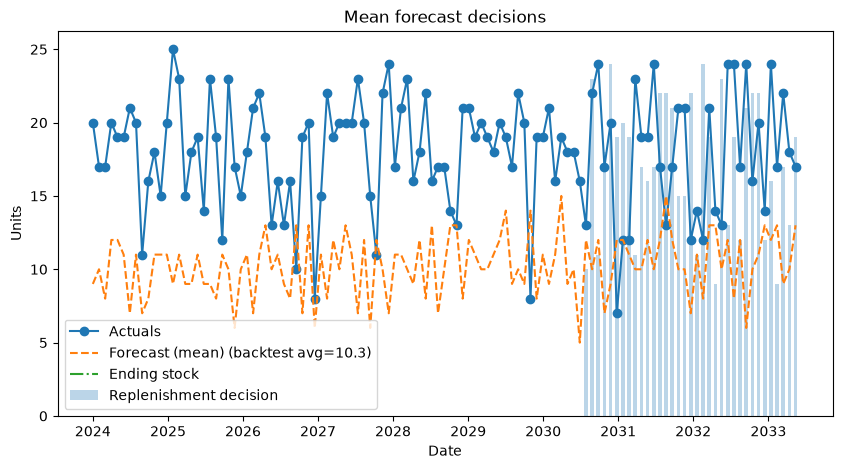

In [6]:
example_id = df["unique_id"].iloc[0]
plot_replenishment_decisions(df, mean_decision_df, unique_id=example_id, title="Mean forecast decisions")

## 2) Percentile-forecast policy
Each percentile forecast already embeds its own buffer, so we compare candidates with `NullSafetyStockStrategy()` and pick the one with the lowest backtest cost.

In [7]:
candidate_targets = sorted(backtest_rows[0].forecast_percentiles) + ["mean"]

def _series_for(target, article_rows):
    if target == "mean":
        return [r.forecast for r in article_rows]
    return [r.forecast_percentiles[target] for r in article_rows]

percentile_costs = {}
for target in candidate_targets:
    policy = ReplenishmentPolicy.order_up_to(
        forecast=TimeSeries.from_values(_series_for(target, backtest_rows)),
        safety_stock=NullSafetyStockStrategy(),
        lead_time=lead_time, review_period=review_period, forecast_horizon=forecast_horizon,
    )
    simulation = simulate_replenishment(
        periods=len(backtest_rows), demand=[r.demand for r in backtest_rows],
        initial_on_hand=backtest_rows[0].initial_on_hand, lead_time=lead_time, policy=policy,
        holding_cost_per_unit=backtest_rows[0].holding_cost_per_unit,
        stockout_cost_per_unit=backtest_rows[0].stockout_cost_per_unit,
        order_cost_per_order=backtest_rows[0].order_cost_per_order,
    )
    percentile_costs[target] = simulation.summary.total_cost

percentile_cost_df = pd.DataFrame(
    [{"target": target, "total_cost": cost} for target, cost in percentile_costs.items()]
).sort_values("total_cost")
best_target = min(percentile_costs, key=percentile_costs.get)
percentile_cost_df

,target,total_cost
4,p90,2392.0
3,p75,2713.0
2,p50,2923.5
5,mean,2923.5
1,p25,3147.0
0,p10,3364.0


('p90', 966.0)

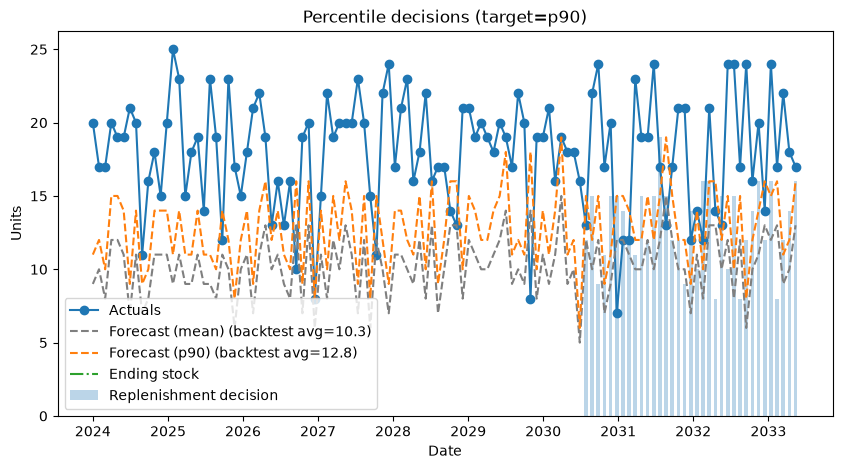

In [8]:
percentile_policy = ReplenishmentPolicy.order_up_to(
    forecast=TimeSeries.from_values(_series_for(best_target, forecast_rows)),
    safety_stock=NullSafetyStockStrategy(),
    lead_time=lead_time, review_period=review_period, forecast_horizon=forecast_horizon,
)
percentile_simulation = simulate_replenishment(
    periods=len(forecast_rows), demand=[r.demand for r in forecast_rows], initial_on_hand=current_stock,
    lead_time=lead_time, policy=percentile_policy,
    holding_cost_per_unit=forecast_rows[0].holding_cost_per_unit,
    stockout_cost_per_unit=forecast_rows[0].stockout_cost_per_unit,
    order_cost_per_order=forecast_rows[0].order_cost_per_order,
)
percentile_decision_rows = [
    ReplenishmentDecisionRow(
        unique_id=row.unique_id, ds=row.ds, quantity=snapshot.order_placed,
        demand=snapshot.demand, incoming_stock=snapshot.received,
        starting_on_hand=snapshot.starting_on_hand, ending_on_hand=snapshot.ending_on_hand,
        on_order=snapshot.on_order, backorders=snapshot.backorders, percentile_target=best_target,
    )
    for row, snapshot in zip(forecast_rows, percentile_simulation.snapshots)
]
percentile_decision_df = replenishment_decision_rows_to_dataframe(percentile_decision_rows, library="pandas")
plot_replenishment_decisions(df, percentile_decision_df, unique_id=example_id, title=f"Percentile decisions (target={best_target})")
best_target, percentile_simulation.summary.total_cost